# From characters to tokens

In *Languages as distributions*, we showed that character frequency distributions already carry enough signal to recover the structure of human languages. Romance languages cluster together, Polish stands alone, and Germanic languages occupy a middle ground.

But a language model does not see characters. It sees **BPE tokens** — subword units produced by a tokenizer trained on a large multilingual corpus. The tokenizer itself is a statistical object: it was built by merging frequent character pairs, and its vocabulary reflects the distribution of subwords across all the languages it was trained on.

This changes things. The tokenizer does not treat all languages equally — it was heavily influenced by the languages that dominated its training data. A language well-represented in that data gets an efficient tokenization (most words map to a single token). A language poorly represented gets fragmented (each word splits into many small pieces).

We repeat the entire pipeline from *Languages as distributions* at the token level, and ask: does the geometry of languages change when seen through the lens of a model's vocabulary?

## 1. Setup & loading

In [1]:
import sys
sys.path.append('../languages-distributions')
sys.path.append('../token-geometry')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import MDS
from matplotlib.patches import Patch
from tqdm import tqdm
import random

from text_loader import load_texts
from metrics import entropy, kl_divergence, hellinger, bhattacharyya
from distance_matrix import compute_distance_matrix
from token_frequencies import load_tokenizer, token_frequencies, token_frequencies_readable
from fertility import fertility_per_language
import visualization as viz_token

# Load texts
texts = load_texts('../data/Books')
languages = list(texts.keys())
print(f"Languages: {languages}")

# Load tokenizer
print("\nLoading XLM-R tokenizer...")
tokenizer = load_tokenizer()
print(f"Vocabulary size: {tokenizer.vocab_size:,} tokens")

c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Languages: ['Dutch', 'English', 'French', 'German', 'Italian', 'Polish', 'Portuguese', 'Spanish']

Loading XLM-R tokenizer...


Vocabulary size: 250,002 tokens


In [2]:
# Compute token distributions for each language
# Note: tokenizing full books takes a moment
print("Computing token distributions...")
token_dists = {}
token_dists_readable = {}

for lang, text in tqdm(texts.items()):
    # Use first 500k characters to keep computation reasonable
    excerpt = text[:500_000]
    token_dists[lang] = token_frequencies(excerpt, tokenizer)
    token_dists_readable[lang] = token_frequencies_readable(excerpt, tokenizer)

print("Done.")
print(f"\nExample — top 5 tokens in French:")
french_top = sorted(token_dists_readable['French'].items(), key=lambda x: x[1], reverse=True)[:5]
for token, freq in french_top:
    print(f"  '{token}': {freq:.4f}")

Computing token distributions...


100%|██████████| 8/8 [00:11<00:00,  1.44s/it]

Done.

Example — top 5 tokens in French:
  ',': 0.0634
  '’': 0.0373
  '.': 0.0242
  '▁de': 0.0238
  's': 0.0186


## 2. Fertility

Tokenizer fertility measures the average number of tokens per word. It is the first and most direct indicator of how well XLM-R handles a given language.

A fertility close to 1 means almost every word maps to a single token — the language is well-represented in the tokenizer's vocabulary. A high fertility means words are systematically broken into smaller pieces — the tokenizer has seen less of this language during its own training.

This is already a form of bias: a language with high fertility requires more tokens to express the same content, which means more computation, more context used, and potentially degraded performance on downstream tasks.

Fertility scores (tokens per word):
  Spanish: 1.501
  English: 1.558
  Portuguese: 1.613
  Italian: 1.675
  Dutch: 1.747
  French: 1.761
  German: 1.765
  Polish: 2.150


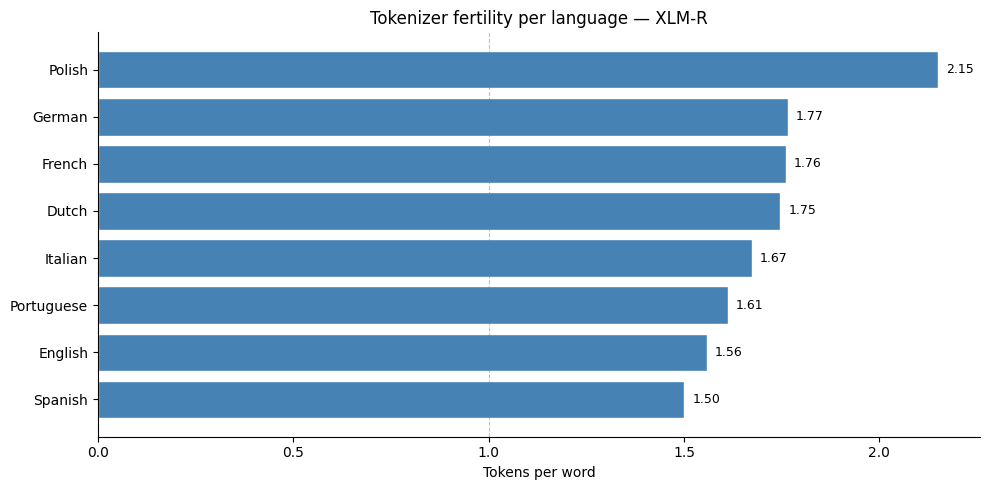

In [3]:
fertility_scores = fertility_per_language(texts, tokenizer)

print("Fertility scores (tokens per word):")
for lang, score in sorted(fertility_scores.items(), key=lambda x: x[1]):
    print(f"  {lang}: {score:.3f}")

viz_token.plot_fertility(fertility_scores)

A few things to note from this chart:

- Languages with simpler morphology and high overlap with XLM-R's training data (English, Portuguese, Spanish) tend to have lower fertility.
- Polish, with its rich inflectional morphology, likely shows higher fertility — many word forms are rare enough that the tokenizer breaks them into subword pieces.
- Fertility is not purely about typology. It is also about how much of each language was in the tokenizer's training corpus. The two effects are hard to disentangle — which is part of what makes this measurement interesting.

## 3. Top 20 tokens per language

Unlike characters, tokens are interpretable — they have names. Looking at the most frequent tokens per language gives us a sense of what the model actually sees when it processes text in that language.

We expect to see short, common subwords dominating: articles, prepositions, common verb stems, and punctuation. The interesting question is whether the most frequent tokens are full words or fragments — which is directly related to fertility.

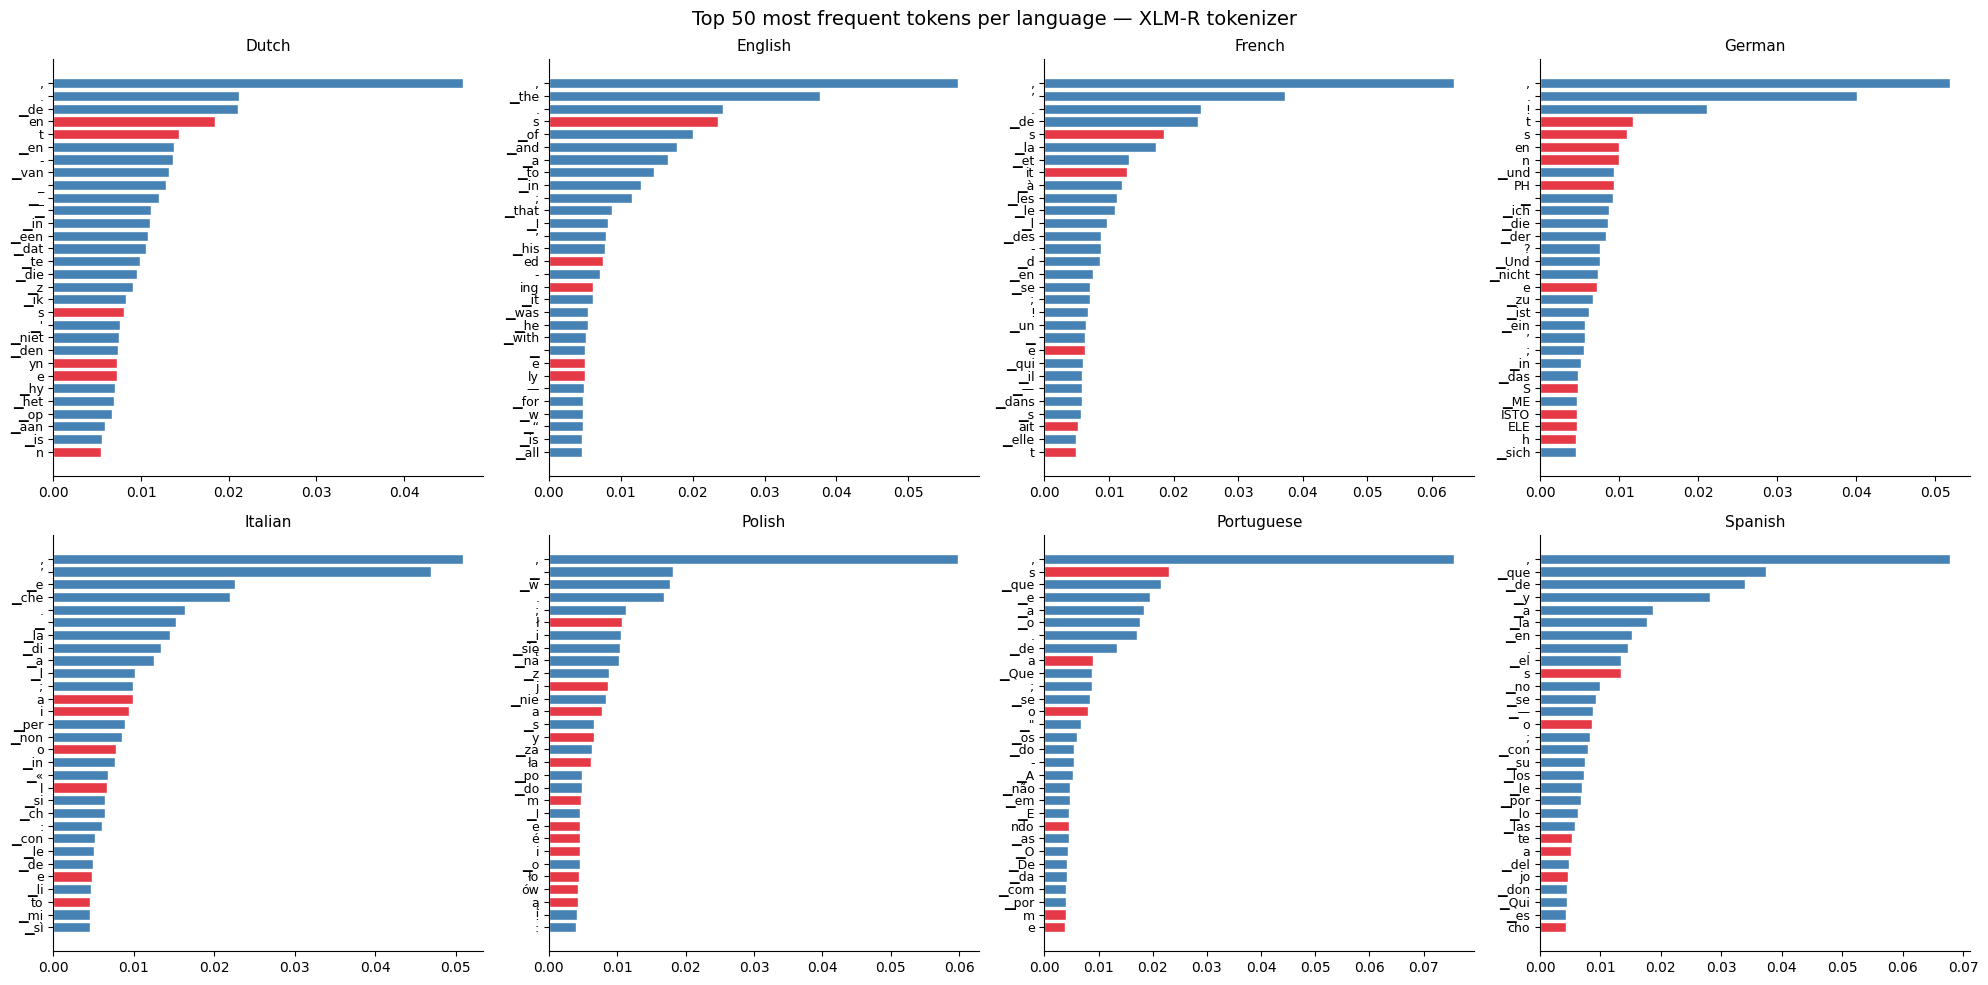

Note: tokens starting with ▁ are word-initial subwords (effectively full words or word starts).
Tokens in red are subword fragments — they only appear in the middle or end of a word.


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Top 50 most frequent tokens per language — XLM-R tokenizer', fontsize=14)

for ax, lang in zip(axes.flatten(), languages):
    top20 = sorted(token_dists_readable[lang].items(), key=lambda x: x[1], reverse=True)[:30]
    tokens = [t[0] for t in top20]
    freqs = [t[1] for t in top20]
    
    # Color fragments (starting with ▁ or containing special chars) differently
    colors = ['#e63946' if not t.startswith('▁') and t.isalpha() else 'steelblue' for t in tokens]
    
    ax.barh(range(len(tokens)), freqs, color=colors, edgecolor='white')
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(lang, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("Note: tokens starting with ▁ are word-initial subwords (effectively full words or word starts).")
print("Tokens in red are subword fragments — they only appear in the middle or end of a word.")

## 4. Entropy per language

We now compute Shannon entropy at the token level. The token vocabulary is much larger than the character alphabet (250k vs 26), so absolute entropy values will be much higher.

A language with high token entropy has a more uniform distribution over the vocabulary — many different tokens appear with similar frequency. A language with low entropy is dominated by a small set of very frequent tokens, which typically corresponds to a language where the tokenizer handles most words efficiently (low fertility, full-word tokens dominate).

Token-level entropy per language:
  Spanish: 9.2142 bits
  French: 9.4034 bits
  Italian: 9.4475 bits
  Dutch: 9.4659 bits
  German: 9.6147 bits
  English: 9.6437 bits
  Portuguese: 9.7759 bits
  Polish: 9.8963 bits


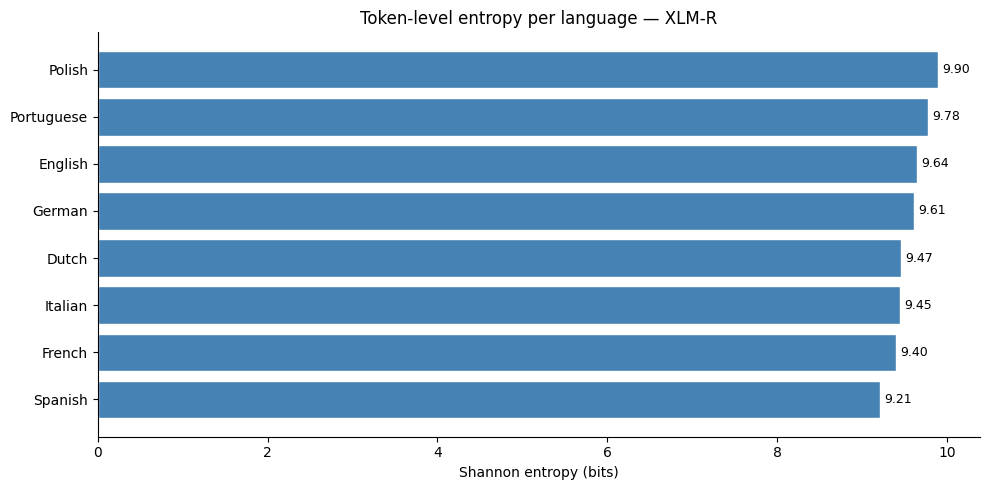

In [8]:
token_entropies = {lang: entropy(dist) for lang, dist in token_dists.items()}

print("Token-level entropy per language:")
for lang, h in sorted(token_entropies.items(), key=lambda x: x[1]):
    print(f"  {lang}: {h:.4f} bits")

langs_sorted = sorted(token_entropies, key=token_entropies.get)
values = [token_entropies[l] for l in langs_sorted]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(langs_sorted, values, color='steelblue', edgecolor='white')
ax.set_xlabel('Shannon entropy (bits)')
ax.set_title('Token-level entropy per language — XLM-R')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, val in zip(bars, values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Distance matrices

We compute pairwise distance matrices at the token level using the same three metrics as in *Languages as distributions*. 

One important difference: token distributions are **much sparser** than character distributions. Two languages may share very few tokens in their top frequencies, which makes KL divergence particularly sensitive — a token that appears in one language but not the other contributes a large penalty. Hellinger and Bhattacharyya are more robust to this sparsity.

In [9]:
METRICS = {
    'KL divergence': kl_divergence,
    'Hellinger': hellinger,
    'Bhattacharyya': bhattacharyya
}

token_matrices = {}
for metric_name in METRICS:
    langs, matrix = compute_distance_matrix(
        token_dists,
        metric=metric_name.lower().replace(' ', '_')
    )
    token_matrices[metric_name] = (langs, matrix)
    print(f"{metric_name} — done")

KL divergence — done
Hellinger — done
Bhattacharyya — done


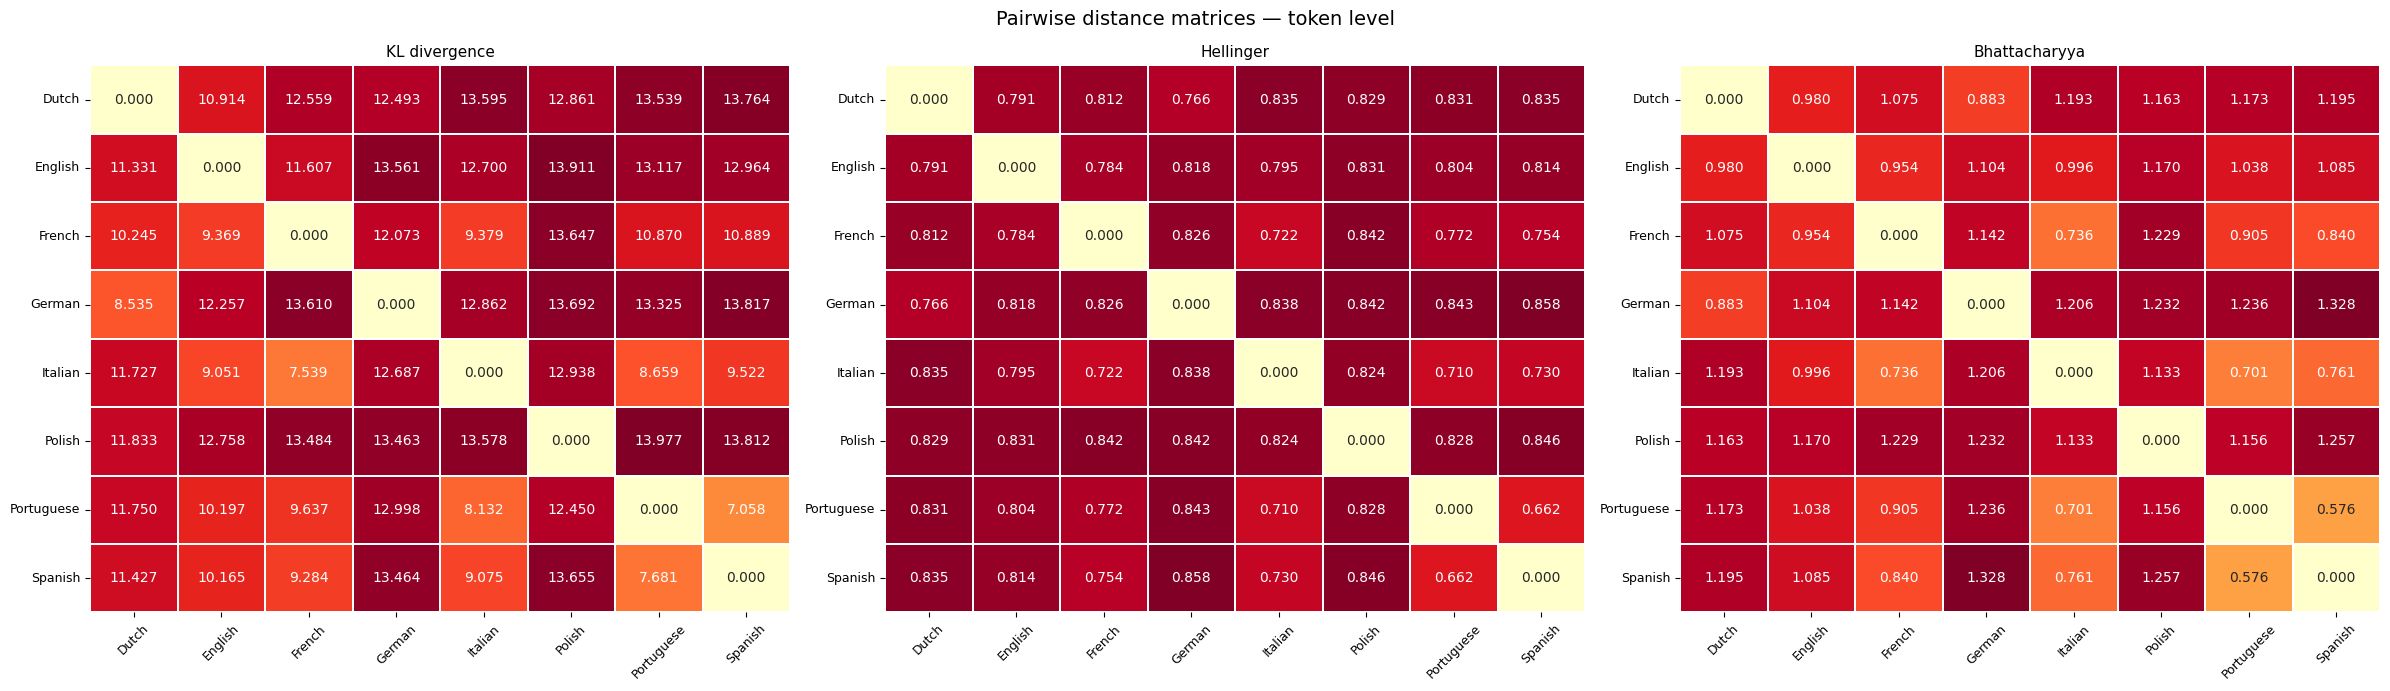

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Pairwise distance matrices — token level', fontsize=14)

for ax, metric_name in zip(axes, METRICS):
    langs, matrix = token_matrices[metric_name]
    sns.heatmap(
        matrix,
        xticklabels=langs,
        yticklabels=langs,
        annot=True,
        fmt='.3f',
        cmap='YlOrRd',
        linewidths=0.3,
        ax=ax,
        cbar=False
    )
    ax.set_title(metric_name, fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.show()

## 6. MDS projections

We project the token-level distance matrices into 2D using MDS. The key question: do language family clusters still emerge at the token level, or does the tokenizer's bias distort the geometry?

c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


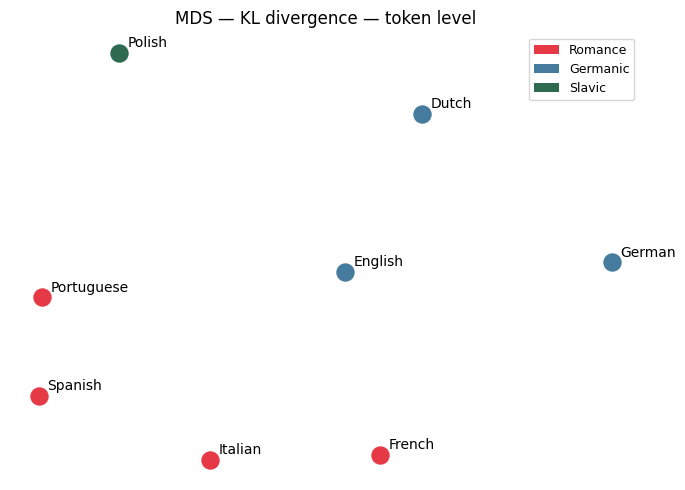

c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


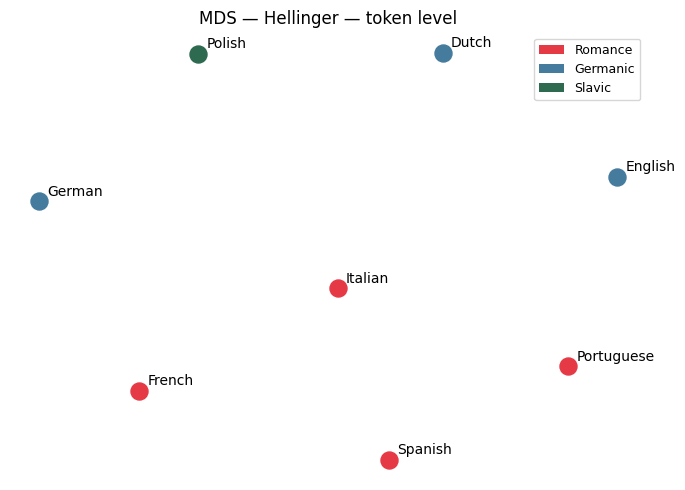

c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


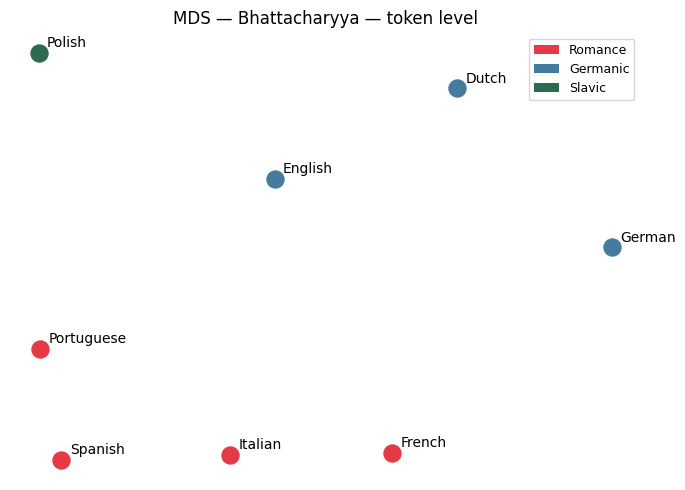

In [11]:
family_colors = {
    'French': '#e63946', 'Italian': '#e63946',
    'Spanish': '#e63946', 'Portuguese': '#e63946',
    'English': '#457b9d', 'German': '#457b9d', 'Dutch': '#457b9d',
    'Polish': '#2d6a4f'
}

legend_elements = [
    Patch(facecolor='#e63946', label='Romance'),
    Patch(facecolor='#457b9d', label='Germanic'),
    Patch(facecolor='#2d6a4f', label='Slavic')
]

for metric_name in METRICS:
    langs, matrix = token_matrices[metric_name]
    matrix_sym = (matrix + matrix.T) / 2
    np.fill_diagonal(matrix_sym, 0)

    reducer = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
    embedding = reducer.fit_transform(matrix_sym)

    fig, ax = plt.subplots(figsize=(7, 5))
    for i, lang in enumerate(langs):
        color = family_colors.get(lang, 'gray')
        ax.scatter(embedding[i, 0], embedding[i, 1], s=150, color=color, zorder=3)
        ax.annotate(lang, (embedding[i, 0], embedding[i, 1]),
                   xytext=(6, 4), textcoords='offset points', fontsize=10)

    ax.set_title(f'MDS — {metric_name} — token level', fontsize=12)
    ax.legend(handles=legend_elements, fontsize=9)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

The answer is clear across all three metrics: **yes, language family structure survives tokenization**. Romance languages (French, Italian, Spanish, Portuguese) consistently cluster together, while Germanic languages (English, German, Dutch) occupy a separate region. Polish remains isolated, as at the character level.

A few notable details:

- **German occasionally drifts** from the Germanic cluster, suggesting its morphological complexity leaves a distinct statistical footprint even at the token level.
- **English sits between the two clusters** in some projections, consistent with its heavy borrowing from Romance languages despite its Germanic roots.
- **The Romance cluster is less tight than at the character level.** At the token level, each language has a more distinctive token vocabulary, even within the same family — the tokenizer reveals finer-grained differences that character frequencies smooth over.

## 7. Detection benchmark

We run the same detection benchmark as in *Languages as distributions*: 50 random extracts of 200 characters per language, detected by minimum distance to reference token distributions.

Token-level detection should is more powerful than character-level — tokens carry more semantic and morphological information.

In [12]:
N_SAMPLES = 50
EXTRACT_LENGTH = 200

def sample_extracts(text, n_samples, length):
    extracts = []
    for _ in range(n_samples):
        start = random.randint(0, len(text) - length)
        extracts.append(text[start:start + length])
    return extracts

def detect_language_tokens(text, lang_token_dists, metric_fn):
    text_dist = token_frequencies(text, tokenizer)
    scores = {lang: metric_fn(text_dist, dist) for lang, dist in lang_token_dists.items()}
    return min(scores, key=scores.get), scores

extracts = {lang: sample_extracts(text, N_SAMPLES, EXTRACT_LENGTH) for lang, text in texts.items()}

token_results = {}
for metric_name, metric_fn in METRICS.items():
    correct = 0
    total = 0
    per_language = {lang: 0 for lang in languages}

    for true_lang, lang_extracts in extracts.items():
        for extract in lang_extracts:
            detected, _ = detect_language_tokens(extract, token_dists, metric_fn)
            if detected == true_lang:
                correct += 1
                per_language[true_lang] += 1
            total += 1

    token_results[metric_name] = {
        'overall': correct / total,
        'per_language': {lang: per_language[lang] / N_SAMPLES for lang in languages}
    }
    print(f"{metric_name}: {correct/total:.1%}")

KL divergence: 100.0%
Hellinger: 100.0%
Bhattacharyya: 100.0%


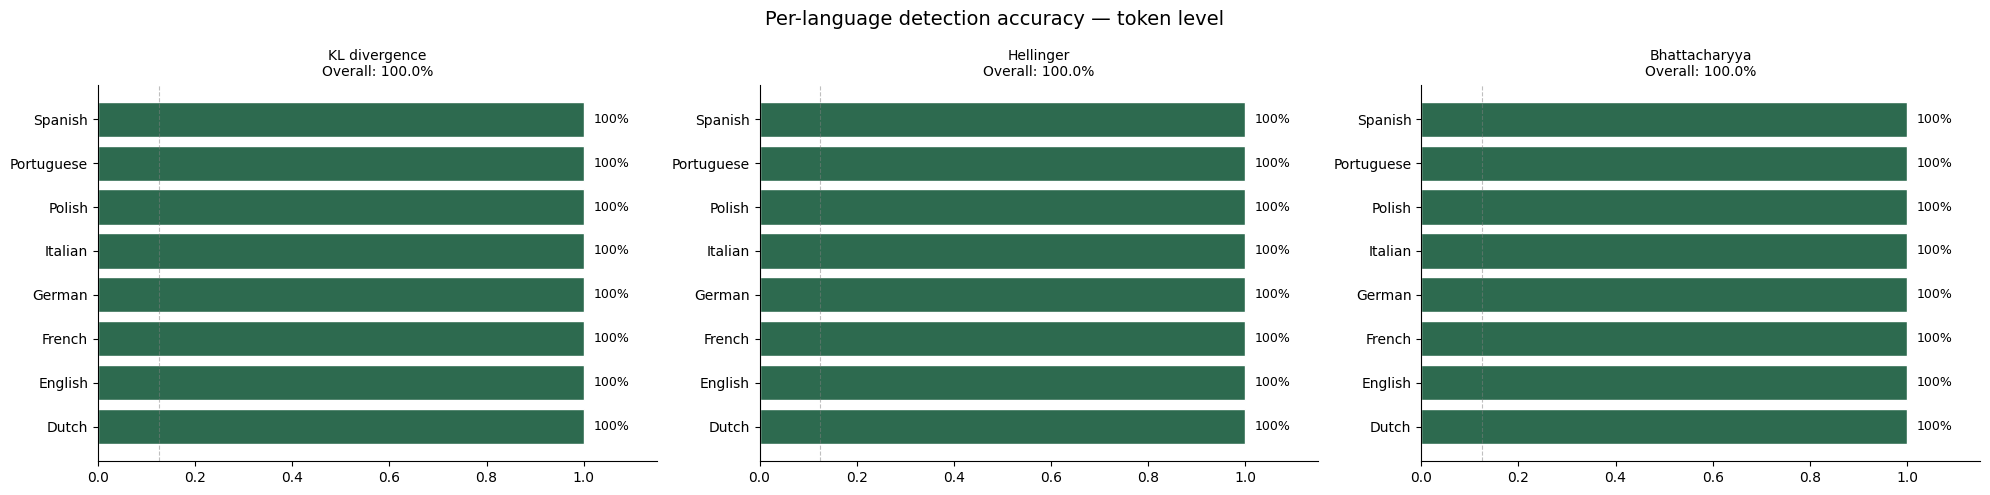

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Per-language detection accuracy — token level', fontsize=14)

for ax, metric_name in zip(axes, METRICS):
    per_lang = token_results[metric_name]['per_language']
    langs_sorted = sorted(per_lang, key=per_lang.get)
    values = [per_lang[l] for l in langs_sorted]
    colors = ['#d62828' if v < 0.5 else '#457b9d' if v < 0.8 else '#2d6a4f' for v in values]

    bars = ax.barh(langs_sorted, values, color=colors, edgecolor='white')
    ax.set_xlim(0, 1.15)
    ax.axvline(x=1/len(languages), color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

    for bar, val in zip(bars, values):
        ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
               f'{val:.0%}', va='center', fontsize=9)

    overall = token_results[metric_name]['overall']
    ax.set_title(f'{metric_name}\nOverall: {overall:.1%}', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 9. Conclusions

We have shown that each language has a statistically distinct token distribution, and that this distribution preserves the structure of language families — the same structure we recovered from character frequencies in *Languages as distributions*. The geometry is consistent across metrics and survives the shift from characters to tokens.

One new element appears at the token level: **fertility**. The tokenizer does not fragment all languages equally, which means some languages are represented more efficiently than others in the model's input space. This asymmetry is structural — it is baked into the tokenizer before any model training happens.

We now have two sets of pairwise distance matrices between our 8 languages — one from character distributions, one from token distributions. In *Predicting LLM bias*, we ask whether these distances correlate with the distances the model itself has learned: the geometry of languages in the embedding space of XLM-R. If they do, it would suggest that the statistical structure of languages — measurable from raw text alone — shapes how a multilingual model represents and treats each language.